# **Import Library**

Penggunaan Library:
- pandas + numpy → manipulasi data
- matplotlib + seaborn → visualisasi data
- sklearn → preprocessing, model, dan evaluasi
- joblib → menyimpan model ke file untuk deployment)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

sns.set_style('whitegrid')

# **EDA**

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khushikyad001/ai-impact-on-jobs-2030")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-jobs-2030' dataset.
Path to dataset files: /kaggle/input/ai-impact-on-jobs-2030


In [5]:
df = pd.read_csv(path + '/AI_Impact_on_Jobs_2030.csv')

print("Ukuran data:", df.shape)
df.head()

Ukuran data: (3000, 18)


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

In [7]:
df.isnull().sum()

,0
Job_Title,0
Average_Salary,0
Years_Experience,0
Education_Level,0
AI_Exposure_Index,0
Tech_Growth_Factor,0
Automation_Probability_2030,0
Risk_Category,0
Skill_1,0
Skill_2,0


### **1. Grafik Distribusi Kategori Risiko (Count Plot)**
Grafik ini berfungsi untuk menampilkan perbandingan jumlah (count) data pekerja dari masing-masing kategori risiko otomatisasi AI (Low, Medium, dan High) yang ada di dalam dataset. Melalui grafik ini, kita bisa mengetahui kategori risiko mana yang paling mendominasi atau paling sedikit di dalam data training model.

Risk_Category
Medium    1521
High       740
Low        739
Name: count, dtype: int64


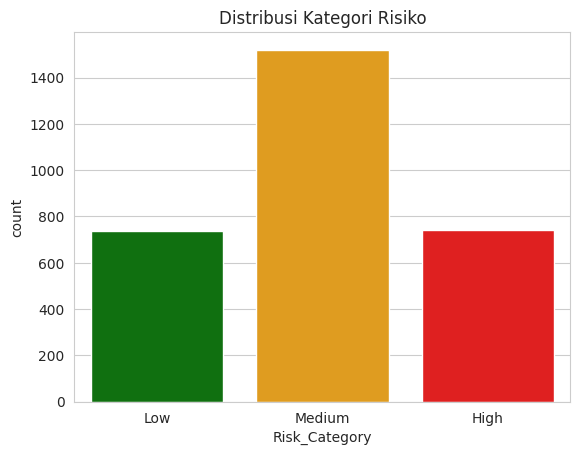

In [17]:
print(df['Risk_Category'].value_counts())

sns.countplot(
    data=df,
    x='Risk_Category',
    hue='Risk_Category',
    order=['Low', 'Medium', 'High'],
    palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
    legend=False
)
plt.title('Distribusi Kategori Risiko')
plt.show()

### **2. Grafik Korelasi Antar Fitur (Heatmap)**
Grafik ini berfungsi untuk melihat hubungan kekuatan dan arah (positif/negatif) antara semua fitur angka di dalam dataset. Grafik ini berguna untuk mengecek fitur mana saja yang saling memengaruhi.

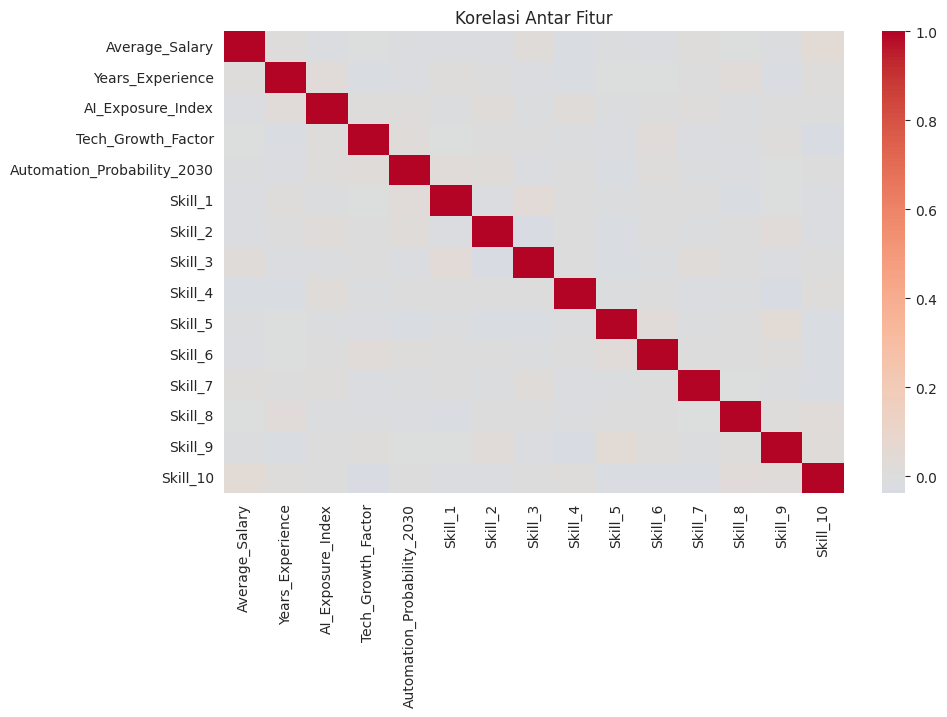

In [19]:
plt.figure(figsize=(10,6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur')
plt.show()

### **3. Grafik Jangkauan Skor Probabilitas tiap Kategori (Box Plot)**
Grafik ini berfungsi untuk melihat sebaran data, nilai tengah (median), serta jangkauan nilai dari skor Automation_Probability_2030 pada masing-masing kelompok risiko (Low, Medium, High).

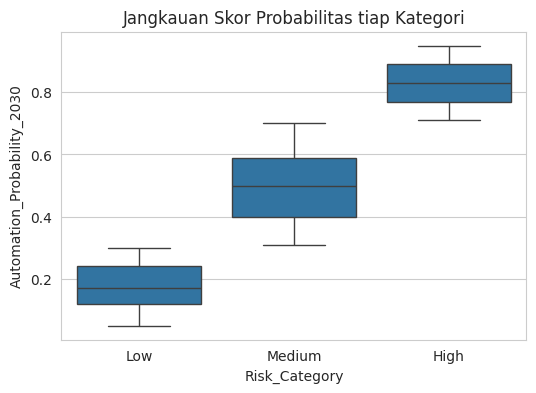

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Risk_Category', y='Automation_Probability_2030',
            order=['Low','Medium','High'])
plt.title('Jangkauan Skor Probabilitas tiap Kategori')
plt.show()

# **Data Preprocessing**

Sebelum data dimasukkan ke dalam model machine learning, kita wajib melakukan serangkaian tahap preprocessing data agar informasi siap diproses oleh algoritma secara optimal. Langkah-langkah krusial tersebut meliputi:

- Mengubah data berbentuk teks menjadi angka karena model hanya bisa memproses input numerik. Langkah ini dilakukan menggunakan ordinal encoding pada fitur Education_Level untuk mempertahankan urutan tingkatannya (0 untuk High School hingga 3 untuk PhD), serta menggunakan LabelEncoder pada variabel target Risk_Category (Low/Medium/High menjadi 0/1/2).

- Mengeliminasi fitur Job_Title dari dataset karena memiliki terlalu banyak kategori unik (20 variasi teks). Langkah penyederhanaan ini diambil untuk mencegah model awal menjadi terlalu kompleks dan menghindari penurunan performa akibat terlalu banyak dimensi data.

- Memisahkan keseluruhan dataset secara acak menjadi dua bagian terpisah, yaitu data latih (training set) sebesar 80% untuk melatih kecerdasan model dan data uji (testing set) sebesar 20%. Pemisahan ini berfungsi sebagai uji coba objektif untuk mengevaluasi akurasi model saat dihadapkan pada data baru yang belum pernah dilihat sebelumnya.

- Menyamakan skala seluruh fitur numerik ke dalam standar yang sama (rata-rata 0 dan standar deviasi 1). Standardisasi ini sangat krusial bagi algoritma seperti Logistic Regression yang sensitif terhadap rentang nilai, sehingga fitur berangka besar seperti Average_Salary tidak akan mendominasi atau "menenggelamkan" fitur-fitur penting lainnya.

In [43]:
edu_order = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
df['Education_Level_Enc'] = df['Education_Level'].map(edu_order)

drop_cols = ['Job_Title', 'Education_Level', 'Risk_Category']
X = df.drop(columns=drop_cols)
y = df['Risk_Category']

print("Fitur yang dipakai:")
print(X.columns.tolist())

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nMapping kelas:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\nJumlah data latih:", X_train.shape)
print("Jumlah data uji  :", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Fitur yang dipakai:
['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Automation_Probability_2030', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10', 'Education_Level_Enc']

Mapping kelas: {'High': 0, 'Low': 1, 'Medium': 2}

Jumlah data latih: (2400, 16)
Jumlah data uji  : (600, 16)


# **Modeling**

## **Model 1: Logistic Regression (Baseline)**

Logistic Regression adalah model klasifikasi yang mencari garis batas (decision boundary) antar kelas dengan cara linear (kombinasi linear dari fitur-fitur, lalu dilewatkan fungsi softmax untuk kasus multi-kelas). Walaupun "regression" ada di namanya, model ini dipakai untuk klasifikasi.


In [31]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Akurasi Logistic Regression: {acc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))


Akurasi Logistic Regression: 0.9967

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       148
         Low       1.00      0.99      0.99       148
      Medium       0.99      1.00      1.00       304

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



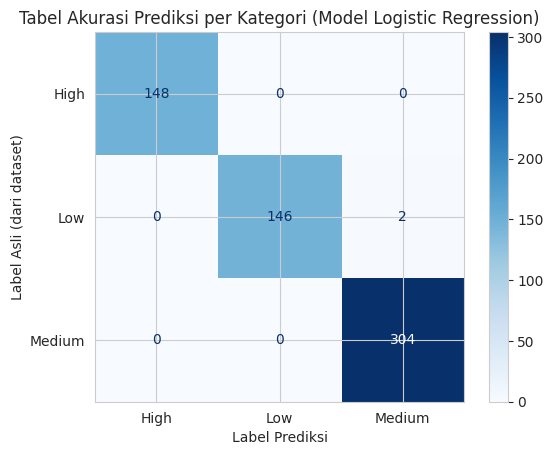

In [48]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=label_encoder.classes_).plot(cmap='Blues')
plt.xlabel('Label Prediksi')
plt.ylabel('Label Asli (dari dataset)')
plt.title('Tabel Akurasi Prediksi per Kategori (Model Logistic Regression)')
plt.show()

# **Model 2: MLPClassifier (Neural Network)**

MLPClassifier (Multi-Layer Perceptron) adalah jenis Neural Network sederhana yang terdiri dari:
- Input layer: menerima fitur (di sini ada 15 fitur)
- Hidden layer(s): layer "tersembunyi" tempat model belajar pola/representasi yang lebih kompleks dan non-linear. Di sini kita pakai 2 hidden layer: 64 neuron lalu 32 neuron.
- Output layer: menghasilkan probabilitas untuk masing-masing kelas (Low/Medium/High)

Berbeda dengan Logistic Regression yang hanya bisa membuat batas linear, Neural Network bisa mempelajari batas keputusan yang non-linear dimana secara teori bisa menangkap pola yang lebih kompleks.

In [33]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Akurasi MLPClassifier: {acc_mlp:.4f}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))


Akurasi MLPClassifier: 0.9350

              precision    recall  f1-score   support

        High       0.93      0.97      0.95       148
         Low       0.91      0.93      0.92       148
      Medium       0.95      0.92      0.94       304

    accuracy                           0.94       600
   macro avg       0.93      0.94      0.93       600
weighted avg       0.94      0.94      0.93       600



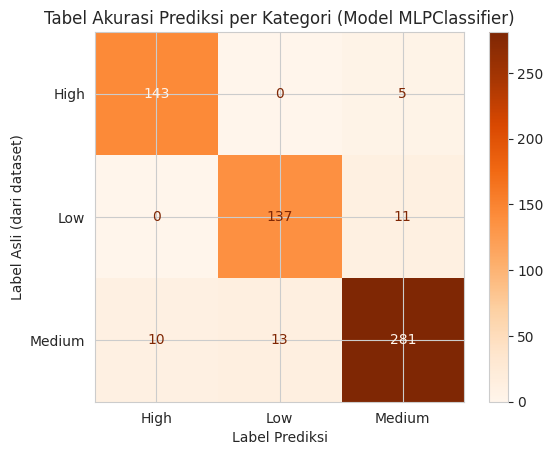

In [49]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=label_encoder.classes_).plot(cmap='Oranges')
plt.xlabel('Label Prediksi')
plt.ylabel('Label Asli (dari dataset)')
plt.title('Tabel Akurasi Prediksi per Kategori (Model MLPClassifier)')
plt.show()

# **Evaluation: Analisis Perbandingan Model**

In [38]:
comparison = pd.DataFrame({
    'Model': ['Model 1: Logistic Regression (Baseline)', 'Model 2: MLPClassifier (Neural Network)'],
    'Accuracy': [acc_lr, acc_mlp]
})
comparison


,Model,Accuracy
0,Model 1: Logistic Regression (Baseline),0.996667
1,Model 2: MLPClassifier (Neural Network),0.935000


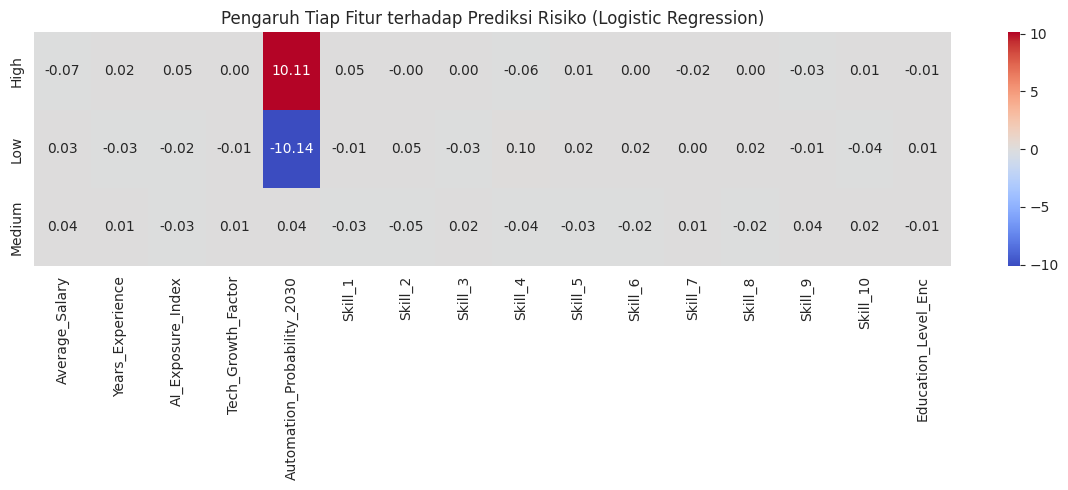

In [50]:
coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=X.columns,
    index=label_encoder.classes_
)
plt.figure(figsize=(12,5))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pengaruh Tiap Fitur terhadap Prediksi Risiko (Logistic Regression)')
plt.tight_layout()
plt.show()

# **Analisis Hasil**

- **Logistic Regression** mendapat akurasi yang sangat tinggi (99-100%), sementara **MLPClassifier** sedikit lebih rendah (93-94%).
- Ini terjadi karena fitur 'Automation_Probability_2030' ternyata memiliki hubungan hampir linear/threshold dengan 'Risk_Category' (dapat dilihat pada boxplot di EDA). Logistic Regression sangat cocok untuk pola seperti ini.
- Neural Network punya kapasitas lebih besar untuk pola non-linear yang kompleks, tetapi untuk kasus ini kapasitas tersebut "tidak terpakai" dan malah berisiko sedikit overfit atau butuh tuning hyperparameter lebih lanjut (misal: ukuran hidden layer, learning rate, jumlah iterasi).

**Kesimpulan**:

Untuk dataset ini, model sederhana (Logistic Regression) sudah sangat efektif sebagai baseline, dan terbukti lebih unggul dibanding model Neural Network.

# **Deployment**

1. **Model terbaik** (Logistic Regression, karena akurasinya lebih tinggi)
2. **Scaler** (untuk memproses input baru dengan skala yang sama seperti saat training)
3. **Label Encoder** (untuk mengubah hasil prediksi angka kembali ke label Low/Medium/High)


In [40]:
joblib.dump(log_reg, 'model_logreg.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("Model, scaler, dan encoder berhasil disimpan!")

Model, scaler, dan encoder berhasil disimpan!
